<a href="https://colab.research.google.com/github/sabithakrishnan/Survival-Models/blob/main/log_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=fdab786774074d35d73a2482d5487e1137bd0926ae40dec6551762321c50b87a
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


<lifelines.LogNormalAFTFitter: fitted with 20 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
   number of observations = 20
number of events observed = 20
           log-likelihood = -66.99
         time fit was run = 2026-09-14 13:27:23 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                     
mu_    is_treatment  1.01      2.74      0.22            0.57            1.44                1.77                4.23
       Intercept     2.13      8.39      0.16            1.82            2.44                6.17               11.42
sigma_ Intercept    -0.70      0.50      0.16           -1.01           -0.39                0.36                0.68

                     cmp to     z      p  -log2(p)
param  covariate                                  
mu_    is_treatment    0.00  4.53 <0.005     17.39
       Intercept       0.00 13.55 <0.005    136.52
sigma_ Intercept       0.00 -4.43 <0.005     16.68
---
Concordance = 0.73
AIC = 139.98
log-likelihood ratio test = 14.13 on 1 df
-log2(p) of ll-ratio test = 12.52

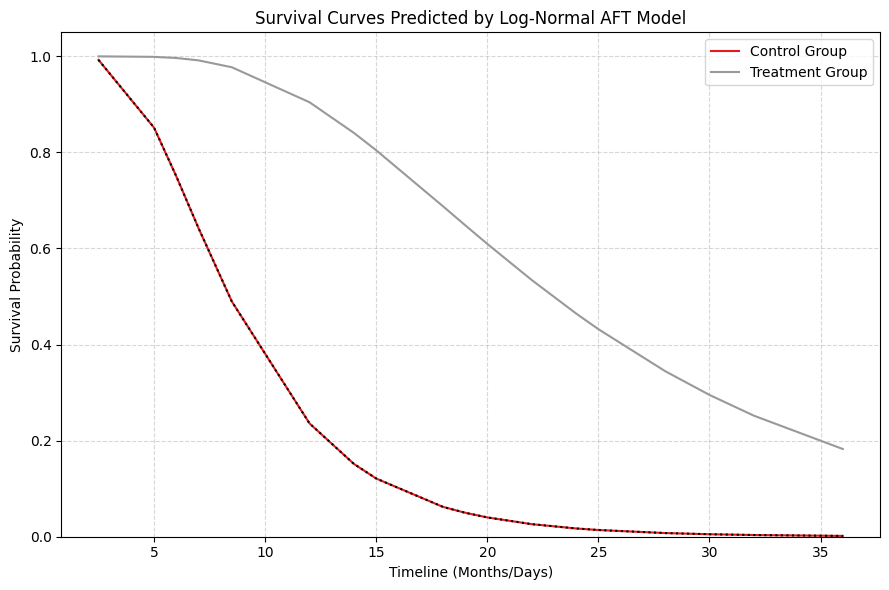

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from lifelines import LogNormalAFTFitter

# 1. Prepare the same sample data
data = {
    'duration': [5, 6, 6, 2.5, 7, 8.5, 12, 15, 18, 20, 12, 14, 19, 22, 24, 25, 28, 30, 32, 36],
    'event_observed': [1]*20,
    'is_treatment': [0]*10 + [1]*10
}
df = pd.DataFrame(data)

# 2. Initialize and fit the Log-Normal AFT Model
ln_aft = LogNormalAFTFitter()
ln_aft.fit(df, duration_col='duration', event_col='event_observed')

# Print summary metrics including the mu (location) and sigma (scale) coefficients
ln_aft.print_summary()

# 3. Plot the predicted survival curves
fig, ax = plt.subplots(figsize=(9, 6))

# Plot partial effects to show survival probability for both groups over time
ln_aft.plot_partial_effects_on_outcome(
    covariates='is_treatment',
    values=[0, 1],
    cmap='Set1',
    ax=ax
)

# 4. Format the plot
ax.set_title('Survival Curves Predicted by Log-Normal AFT Model')
ax.set_xlabel('Timeline (Months/Days)')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(['Control Group', 'Treatment Group'])

plt.tight_layout()
plt.show()